# Explicabilidad en LLMs Locales: Integrated Gradients desde Cero

Este notebook implementa **Integrated Gradients (IG)** para un modelo de lenguaje de Hugging Face. A diferencia de métodos agnósticos al modelo que perturban la entrada (como LIME o KernelSHAP), IG aprovecha el acceso a los pesos internos de la red neuronal para calcular la atribución exacta mediante el teorema fundamental del cálculo.

La fórmula que aproximaremos mediante una suma de Riemann es:
$$IG_i(x) = (x_i - x'_i) \times \int_{\alpha=0}^{1} \frac{\partial F(x' + \alpha(x-x'))}{\partial x_i} d\alpha$$

Donde $x$ es nuestra entrada real, $x'$ es el baseline (ceros) y $\alpha$ es el factor de interpolación.

In [1]:
 !pip install transformers torch matplotlib seaborn pandas captum


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# Instalar dependencias si estás en Colab o un entorno nuevo
 #!pip install transformers torch matplotlib seaborn pandas

import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from transformers import AutoModelForSequenceClassification, AutoTokenizer

# Configuramos visualizaciones
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

/Users/nadiatamayo/miniconda3/envs/deeplearning_curso/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import os
from getpass import getpass
from huggingface_hub import login

hf_token = getpass("Pega tu HF token (input oculto, Enter para omitir): ").strip()
login(token=hf_token, add_to_git_credential=False)

In [4]:
from huggingface_hub import whoami

try:
    user_info = whoami()
    print(f"✓ Autenticado como: {user_info['name']}")
    print(f"✓ Token válido")
except Exception as e:
    print(f"✗ Error de autenticación: {e}")
    print("Probablemente el token está vacío o expirado.")

✓ Autenticado como: Nad3045
✓ Token válido


In [5]:
import os, time

# Modelo pequeno y estable para sentimiento (2 clases)
model_name = "distilbert-base-uncased-finetuned-sst-2-english"

start = time.perf_counter()
tokenizer = AutoTokenizer.from_pretrained(model_name, token=hf_token)
model = AutoModelForSequenceClassification.from_pretrained(model_name, token=hf_token)
model.eval()

elapsed = time.perf_counter() - start
print(f"✓ Cargado en {elapsed:.1f}s")
print("Clases del modelo:", model.config.id2label)

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 6446.77it/s]

✓ Cargado en 93.6s
Clases del modelo: {0: 'NEGATIVE', 1: 'POSITIVE'}


## Implementación del Algoritmo

A continuación, encapsulamos la lógica en una función reutilizable. El proceso sigue estos pasos:
1. Obtener los IDs de los tokens y los embeddings originales.
2. Crear tensores interpolados entre un vector de ceros y los embeddings originales.
3. Hacer *forward pass* usando `inputs_embeds` y calcular gradientes.
4. Integrar (promediar) los gradientes y multiplicar por la entrada original.

In [6]:
def calcular_ig(texto, clase_objetivo, modelo, tokenizador, m_steps=50):
    # 1. Tokenización y obtención de Embeddings base
    inputs = tokenizador(texto, return_tensors="pt")
    input_ids = inputs["input_ids"]
    tokens = tokenizador.convert_ids_to_tokens(input_ids[0])
    
    embeddings_layer = modelo.get_input_embeddings()
    input_embeddings = embeddings_layer(input_ids).detach()
    baseline_embeddings = torch.zeros_like(input_embeddings)
    
    # 2. Generar interpolaciones
    interpolated_embeddings = [
        baseline_embeddings + (i / m_steps) * (input_embeddings - baseline_embeddings)
        for i in range(m_steps + 1)
    ]
    
    gradients = []
    
    # 3. Calcular gradientes para cada paso
    for emb in interpolated_embeddings:
        emb = emb.clone().detach().requires_grad_(True)
        modelo.zero_grad()
        
        # Forward pass directo con embeddings
        outputs = modelo(inputs_embeds=emb)
        score = outputs.logits[0, clase_objetivo]
        
        # Backpropagation
        score.backward()
        gradients.append(emb.grad.clone())
        
    # 4. Aproximar la integral
    stacked_gradients = torch.stack(gradients)
    avg_gradients = torch.mean(stacked_gradients, dim=0)
    
    # Multiplicar por (Input - Baseline)
    integrated_gradients = (input_embeddings - baseline_embeddings) * avg_gradients
    
    # Obtener la norma L2 (magnitud de la contribución por token)
    # y enviarla a CPU/Numpy para graficar
    token_attributions = torch.norm(integrated_gradients, dim=-1).squeeze().detach().numpy()
    
    return tokens, token_attributions

Analizando atribución para la clase: NEGATIVE


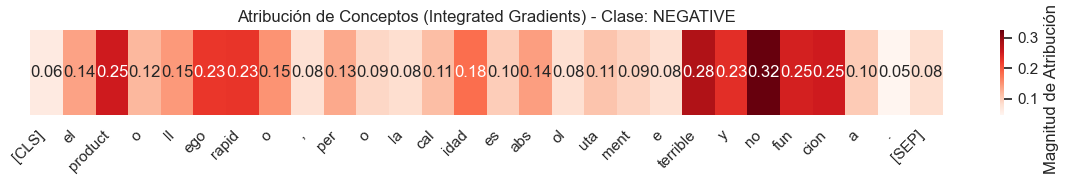

In [7]:
# Probemos con una frase de ejemplo
texto_prueba = "El producto llegó rápido, pero la calidad es absolutamente terrible y no funciona."

# En este modelo: 0 = NEGATIVE, 1 = POSITIVE
clase_analizar = 0
print(f"Analizando atribución para la clase: {model.config.id2label[clase_analizar]}")

tokens, attributions = calcular_ig(
    texto=texto_prueba,
    clase_objetivo=clase_analizar,
    modelo=model,
    tokenizador=tokenizer,
    m_steps=50
)

# Limpiamos un poco los tokens especiales de subword para la gráfica
clean_tokens = [t.replace("Ġ", "").replace("##", "") for t in tokens]

# Crear un DataFrame para facilitar la graficación
df_attr = pd.DataFrame({
    "Token": clean_tokens,
    "Importancia": attributions
})

# Graficar un mapa de calor (Heatmap) horizontal
plt.figure(figsize=(12, 2))
sns.heatmap(
    data=[df_attr["Importancia"].values],
    xticklabels=df_attr["Token"].values,
    yticklabels=False,
    cmap="Reds",
    cbar_kws={"label": "Magnitud de Atribución (IG)"},
    annot=True,
    fmt=".2f"
)
plt.title(f"Atribución de Conceptos (Integrated Gradients) - Clase: {model.config.id2label[clase_analizar]}")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Validación con Librerías de Producción (Captum)

Escribir el algoritmo desde cero es excelente para entender la teoría, pero en un entorno de producción necesitamos herramientas optimizadas. **Captum**, la librería oficial de interpretabilidad de PyTorch, nos ofrece implementaciones robustas de Integrated Gradients.

A continuación, usaremos `LayerIntegratedGradients` de Captum para calcular las atribuciones y compararlas con nuestro código manual. Notarás que Captum maneja automáticamente la creación del baseline y la aproximación de la integral.

In [ ]:
from captum.attr import LayerIntegratedGradients
from captum.attr import visualization as viz

print("Calculando atribuciones con Captum...")

# 1. Preparar la entrada
texto_prueba = "El producto llegó rápido, pero la calidad es absolutamente terrible y no funciona."
inputs = tokenizer(texto_prueba, return_tensors="pt")
input_ids = inputs["input_ids"]
attention_mask = inputs["attention_mask"]

# 2. Definir una función wrapper para el forward pass
# Captum llamará esta función con input_ids y argumentos adicionales
def forward_func(input_ids, attention_mask):
    outputs = model(input_ids=input_ids, attention_mask=attention_mask)
    return outputs.logits

# 3. Inicializar LayerIntegratedGradients sobre la capa de embeddings
capa_embeddings = model.get_input_embeddings()
lig = LayerIntegratedGradients(forward_func, capa_embeddings)

# 4. Calcular la atribución
attributions, delta = lig.attribute(
    inputs=input_ids,
    additional_forward_args=(attention_mask,),
    target=clase_analizar,
    n_steps=50,
    return_convergence_delta=True
)

# 5. Condensar valores por token con norma L2 (consistente con la version manual)
# attributions shape: (1, num_tokens, embedding_dim)
attributions_norm = torch.norm(attributions, dim=-1).squeeze(0).detach().numpy()

print(f"Error de convergencia (Delta): {delta.item():.4f}")
print("¡Cálculo completado!")

Calculando atribuciones con Captum...


RuntimeError: The size of tensor a (28) must match the size of tensor b (768) at non-singleton dimension 2

In [ ]:
# Preparar los tokens y la predicción para la visualización
tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
clean_tokens = [t.replace('Ġ', '') for t in tokens]

# Obtener la probabilidad real de la clase predecida
with torch.no_grad():
    logits = model(input_ids).logits
    probs = torch.nn.functional.softmax(logits, dim=-1)
    prob_objetivo = probs[0, clase_analizar].item()

# Crear el registro de visualización
score_vis = viz.VisualizationDataRecord(
    word_attributions=attributions_norm,
    pred_prob=prob_objetivo,
    pred_class=model.config.id2label[clase_analizar],
    true_class=model.config.id2label[clase_analizar], # Asumimos que la predicción es correcta para el ejemplo
    attr_class=model.config.id2label[clase_analizar],
    attr_score=attributions_norm.sum(),
    raw_input_ids=clean_tokens,
    convergence_score=delta.item()
)

# Mostrar la tabla HTML
print("Comparativa visual generada por Captum:")
viz.visualize_text([score_vis])